## Business Understanding

This is a synthetic dataset for training and testing spam detection models. It contains 20,000 email samples, and each sample is described by five features and one label.
es, and each sample is described by five features and one label.

Features:
num_links

Type: Integer
Meaning: Number of links present in the email body
Generated using a Poisson distribution with an average (λ) of 1.5
Assumption: More links often mean higher chances of spam
num_words

Type: Integer
Meaning: Total number of words in the email
Randomly picked between 20 and 200
Assumption: Short or overly long emails might look suspicious, but this is more of a neutral feature
has_offer

Type: Binary (0 or 1)
Meaning: Whether the email contains the word “offer”
Simulated using a binomial distribution (30% chance of being 1)
Assumption: Marketing language like “offer” is common in spam
sender_score

Type: Float between 0 and 1
Meaning: A simulated reputation score of the email sender
Normally distributed around 0.7, clipped to stay between 0 and 1
Assumption: A low sender score means the sender is less trustworthy (and more likely to send spam)
all_caps

Type: Binary (0 or 1)
Meaning: Whether the subject line is written in ALL CAPS
Simulated with a 10% chance of being 1
Assumption: All-caps subject lines are usually attention-grabbing and common in spam
Target:
is_spam
Type: Binary (0 or 1)
Meaning: Whether the email is spam
Generated using a rule-based formula:
Spam probability increases if:
Links > 2
It contains an “offer”
Sender score < 0.4
Subject is in all caps
These factors are combined with different weights
A little noise is added using Gaussian randomness to simulate real-world uncertainty
Emails are labeled as spam if the final probability crosses 0.5

Data Understanding

- loading
- head and tail( glimpse of how the data looks like)
- shape
- info()
- data types
- descritptive stats (categorical)
- descritptive stats (numerical)
- missing values (data integrity)
- duplicate(data integrity)
- visualization

## loading libraries

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as stat

## loading dataset

In [137]:
spam_df= pd.read_csv("data/spam_detection_dataset.csv")

## glimpse of the data

In [138]:
spam_df.head()

,num_links,num_words,has_offer,sender_score,all_caps,is_spam
0,3,98,1,0.718607,0,0
1,0,170,0,0.698901,1,0
2,0,38,0,0.620466,0,0
3,0,116,0,0.701755,0,0
4,3,89,1,0.583621,1,1


In [139]:
spam_df.tail()

,num_links,num_words,has_offer,sender_score,all_caps,is_spam
19995,1,22,1,0.614551,0,0
19996,3,154,0,1.000000,1,1
19997,4,109,0,0.935848,1,0
19998,2,197,0,0.481772,0,0
19999,0,116,0,0.566640,0,0


In [140]:
spam_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   num_links     20000 non-null  int64  
 1   num_words     20000 non-null  int64  
 2   has_offer     20000 non-null  int64  
 3   sender_score  20000 non-null  float64
 4   all_caps      20000 non-null  int64  
 5   is_spam       20000 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 937.6 KB


In [141]:
spam_df.dtypes

num_links         int64
num_words         int64
has_offer         int64
sender_score    float64
all_caps          int64
is_spam           int64
dtype: object

In [142]:
rows, columns = spam_df.shape
output = f"This data set has  {rows} RECORDS and  {columns} FEATURES"
print(output)

This data set has  20000 RECORDS and  6 FEATURES


In [143]:
spam_df.columns

Index(['num_links', 'num_words', 'has_offer', 'sender_score', 'all_caps',
       'is_spam'],
      dtype='str')

## missing and duplicates

In [144]:
spam_df.isna().sum() ## no missing values

num_links       0
num_words       0
has_offer       0
sender_score    0
all_caps        0
is_spam         0
dtype: int64

In [145]:
spam_df.duplicated().sum()

np.int64(402)

In [146]:
spam_df.duplicated().sum() *100/len(spam_df) 

np.float64(2.01)

insight:
- we have 402 duplicated values making 2.01% of the total data set

In [147]:
spam_df_1= spam_df_1.drop_duplicates() ## drop duplicates
spam_df_1

,level_0,index,num_links,num_words,has_offer,sender_score,all_caps,is_spam
0,0,0,3,98,1,0.718607,0,0
1,1,1,0,170,0,0.698901,1,0
2,2,2,0,38,0,0.620466,0,0
3,3,3,0,116,0,0.701755,0,0
4,4,4,3,89,1,0.583621,1,1
...,...,...,...,...,...,...,...,...
19593,19593,19995,1,22,1,0.614551,0,0
19594,19594,19996,3,154,0,1.000000,1,1
19595,19595,19997,4,109,0,0.935848,1,0
19596,19596,19998,2,197,0,0.481772,0,0


In [148]:
spam_df_1.duplicated().sum() *100/len(spam_df_1) 

np.float64(0.0)

In [149]:
spam_df_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 19598 entries, 0 to 19597
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   level_0       19598 non-null  int64  
 1   index         19598 non-null  int64  
 2   num_links     19598 non-null  int64  
 3   num_words     19598 non-null  int64  
 4   has_offer     19598 non-null  int64  
 5   sender_score  19598 non-null  float64
 6   all_caps      19598 non-null  int64  
 7   is_spam       19598 non-null  int64  
dtypes: float64(1), int64(7)
memory usage: 1.2 MB


In [150]:
rows, columns = spam_df_1.shape
output = f"This data set has  {rows} RECORDS and  {columns} FEATURES"
print(output)

This data set has  19598 RECORDS and  8 FEATURES


## descriptive stats (numerical and categorical)

In [151]:
spam_df_1.describe()

,level_0,index,num_links,num_words,has_offer,sender_score,all_caps,is_spam
count,19598.000000,19598.000000,19598.000000,19598.000000,19598.000000,19598.000000,19598.000000,19598.000000
mean,9798.500000,9936.594091,1.503980,109.555771,0.305286,0.687977,0.099347,0.093530
std,5657.599624,5778.993738,1.225113,52.021015,0.460540,0.185019,0.299135,0.291181
min,0.000000,0.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4899.250000,4922.250000,1.000000,64.000000,0.000000,0.563561,0.000000,0.000000
50%,9798.500000,9903.500000,1.000000,110.000000,0.000000,0.694875,0.000000,0.000000
75%,14697.750000,14940.750000,2.000000,155.000000,1.000000,0.823769,0.000000,0.000000
max,19597.000000,19999.000000,9.000000,199.000000,1.000000,1.000000,1.000000,1.000000


insights:

*num links* Assumption: More links often mean higher chances of spam
- Mean: 1.50
- Maximum of  9 links 
- Most emails(range): 1–2 links
- This matches your Poisson assumption (λ ≈ 1.5)
- Since spam increases when links > 2,a small portion strongly triggers spam

*has_offer* Simulated using a binomial distribution (30% chance of being 1)
Assumption: Marketing language like “offer” is common in spam
- a (average) Mean of  0.305 implying 30% of the  emails contain "offer" in them
- this Matches our design (binomial 30%)
- Spam often uses promotional language- This is a strong spam indicator

*sender score* Assumption: A low sender score means the sender is less trustworthy (and more likely to send spam)
- Mean: 0.687977 (~0.7 expected)
- 25% of emails < 0.563561
- 75% of the emails fall below 0.823769
- Spam rule triggers when < 0.4 ,Strong negative relationship with spam

*all caps* Simulated with a 10% chance of being 1
Assumption: All-caps subject lines are usually attention-grabbing and common in spam
- Mean is at 0.099 approximated 10% of the emails
- Rare but impactful
- Matches our assumption
Weak individually, but boosts spam probability when combined

*is spam* Meaning: Whether the email is spam
-Mean is at 0.0935 implying aprox 9.3% of the emails are  spam
- Spam is relatively rare
- This is realistic (most emails are not spam)

In [152]:
spam_df_1.describe(include='all')

,level_0,index,num_links,num_words,has_offer,sender_score,all_caps,is_spam
count,19598.000000,19598.000000,19598.000000,19598.000000,19598.000000,19598.000000,19598.000000,19598.000000
mean,9798.500000,9936.594091,1.503980,109.555771,0.305286,0.687977,0.099347,0.093530
std,5657.599624,5778.993738,1.225113,52.021015,0.460540,0.185019,0.299135,0.291181
min,0.000000,0.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4899.250000,4922.250000,1.000000,64.000000,0.000000,0.563561,0.000000,0.000000
50%,9798.500000,9903.500000,1.000000,110.000000,0.000000,0.694875,0.000000,0.000000
75%,14697.750000,14940.750000,2.000000,155.000000,1.000000,0.823769,0.000000,0.000000
max,19597.000000,19999.000000,9.000000,199.000000,1.000000,1.000000,1.000000,1.000000


In [153]:
spam_df_1.describe(include='object')

ValueError: No columns match the specified include or exclude data types

In [ ]:
links=spam_df_1['num_links'].value_counts()
links

num_links
1    6550
2    4962
0    4341
3    2471
4     900
5     278
6      80
7      11
8       4
9       1
Name: count, dtype: int64

In [ ]:
isspam=spam_df_1['is_spam'].value_counts()
isspam

is_spam
0    17765
1     1833
Name: count, dtype: int64

In [ ]:
spam_df_2 = spam_df_1[['num_links','is_spam']].copy().reset_index(drop=True)
spam_df_2.head()

,num_links,is_spam
0,3,0
1,0,0
2,0,0
3,0,0
4,3,1


In [ ]:
spam_df_2.tail()

,num_links,is_spam
19593,1,0
19594,3,1
19595,4,0
19596,2,0
19597,0,0


## visualization

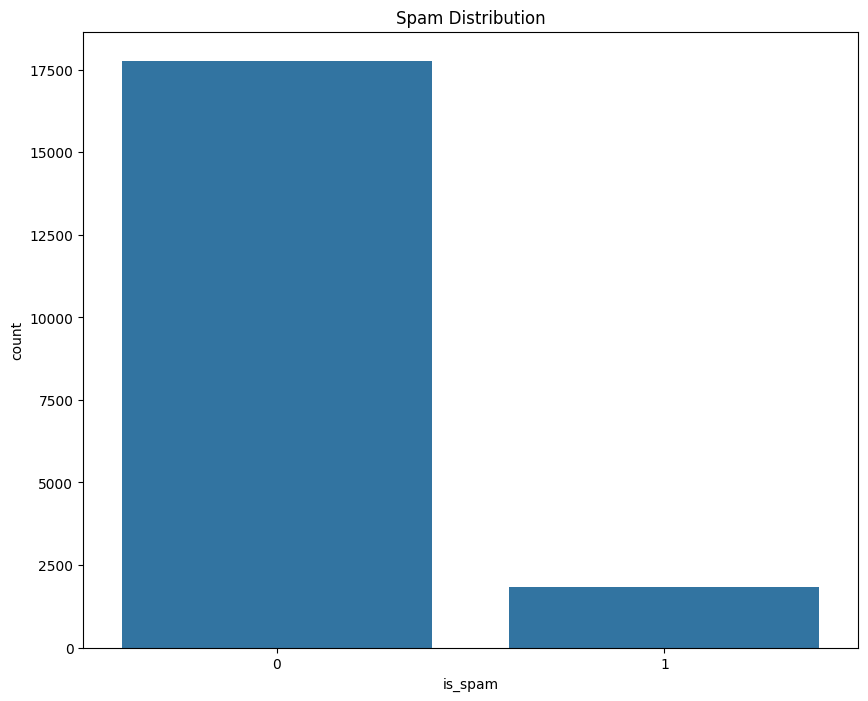

In [ ]:
plt.figure(figsize=(10, 8))
sns.countplot(x='is_spam', data=spam_df_1)
plt.title('Spam Distribution')
plt.show()

insight:

Type: Binary (0 or 1)
Meaning: Whether the email is spam
Emails are labeled as spam if the final probability crosses 0.5

In [ ]:
# If needed: drop index columns
spam_df = spam_df.drop(columns=['level_0','index'], errors='ignore')

# Parameters for Poisson (matches dataset generation)
lam_links = 1.5

# Max number of links in dataset for plotting
max_links = spam_df['num_links'].max()
link_values = np.arange(0, max_links+1)

In [ ]:
#PMF: Probability of exact number of links

from scipy.stats import poisson
import numpy as np

# Parameters
lam_links = 1.5
link_values = np.arange(0, 10)  # 0 to max links in your dataset

# PMF: probability of exactly k links
pmf_values = poisson.pmf(link_values, mu=lam_links)
pmf_values

array([2.23130160e-01, 3.34695240e-01, 2.51021430e-01, 1.25510715e-01,
       4.70665182e-02, 1.41199554e-02, 3.52998886e-03, 7.56426185e-04,
       1.41829910e-04, 2.36383183e-05])

insight:
- Most emails have 0–2 links, which matches the mean of 1.5.
- Probability drops sharply for 3+ links, so emails with many links are rare and are  often spam.

In [ ]:
# CDF: Probability of <= k links

cdf_values = poisson.cdf(link_values, mu=lam_links)
cdf_values

array([0.22313016, 0.5578254 , 0.80884683, 0.93435755, 0.98142406,
       0.99554402, 0.99907401, 0.99983043, 0.99997226, 0.9999959 ])

In [ ]:
# 3. Visualize PMF and CDF
plt.figure(figsize=(12,5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

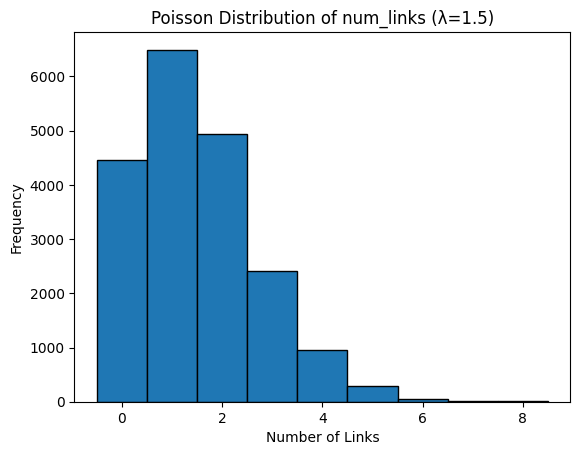

In [ ]:
plt.hist(num_links, bins=range(0,10), edgecolor='black', align='left')
plt.title("Poisson Distribution of num_links (λ=1.5)")
plt.xlabel("Number of Links")
plt.ylabel("Frequency")
plt.show()

In [ ]:
mean = spam_df_1['has_offer'].mean()
variance = spam_df_1['has_offer'].var()
print(f"Mean: {mean} || Variance: {variance}")

Mean: 0.3052862536993571 || Variance: 0.21209737940076268


In [ ]:
mean = spam_df_1['num_links'].mean()
variance = spam_df_1['num_links'].var()
print(f"Mean: {mean} || Variance: {variance}")

Mean: 1.5039799979589754 || Variance: 1.5009026667428278


insight:
mean==mode==median

In [ ]:
# Probability of exactly 3 links
prob_3_links = poisson.pmf(3, mu=lam)
print("P(num_links = 3) =", prob_3_links)

# Probability of 3 or fewer links
prob_3links_orfewer = poisson.cdf(3, mu=lam)
print("P(num_links <= 3) =", prob_3links_orfewer)

NameError: name 'poisson' is not defined

In [ ]:
# Parameters
lam =1.5        # λ (average number of links)
n = 19598 # number of emails

# Generate Poisson-distributed num_links
num_links = np.random.poisson(lam=lam, size=n)

print(num_links[:100])  # preview first 100 values

[3 1 1 4 3 2 0 3 1 1 1 1 3 0 1 0 3 1 1 2 2 2 1 4 0 1 1 1 0 5 1 2 1 2 4 1 1
 4 5 0 0 2 2 2 0 0 2 0 1 0 0 1 1 3 0 0 1 0 2 3 0 1 3 1 0 1 1 2 0 1 0 2 2 0
 3 0 2 3 3 3 0 3 1 0 1 2 4 1 2 4 0 2 3 1 2 0 3 1 1 0]
